PREPROCESAMIENTO DATOS - NODO 4

In [1]:
import pandas as pd
import numpy as np

FILE_PATH = "year_all.csv"
NODE_ID = 4
FREQ = "10min"

PERIODOS = [
    ("2018-07-10", "2018-11-04 23:59:59"),
    ("2019-05-15", "2019-10-15 23:59:59"),
    ("2021-05-15", "2021-10-15 23:59:59"),
    ("2022-05-21", "2022-10-15 23:59:59"),
    ("2023-04-15", "2023-09-15 23:59:59"),
]

data = pd.read_csv(FILE_PATH)
data["instante"] = pd.to_datetime(data["instante"])

# Eliminar HA incorrecta y renombrar var9 → HA
data = data.drop(columns=["HA"], errors="ignore")
data = data.drop(columns=["goteros_linea"], errors="ignore")
data = data.rename(columns={"var9": "HA"})

# Solo nodo 4
df_node = data[data["id_nodo"] == NODE_ID].copy()
df_node = df_node.sort_values("instante")
df_node = df_node.drop(columns=["id_nodo"], errors="ignore")

Cálculo del intervalo más frecuente de muestreo

In [2]:
def slice_period(df, start, end):
    start = pd.to_datetime(start); end = pd.to_datetime(end)
    return df[(df["instante"] >= start) & (df["instante"] <= end)].copy()

def most_frequent_sampling_interval(df):
    dt_seconds = df["instante"].sort_values().diff().dt.total_seconds()

    dt_seconds = dt_seconds.dropna()
    dt_seconds = dt_seconds[dt_seconds > 0]

    if dt_seconds.empty:
        return None, dt_seconds

    mode_val = dt_seconds.mode()
    most_freq = mode_val.min()
    return most_freq, dt_seconds

df_all_periods = pd.concat([slice_period(df_node, a, b) for a, b in PERIODOS], ignore_index=True)
most_freq_global, dt_seconds_global = most_frequent_sampling_interval(df_all_periods)

print("\n=== Intervalo más frecuente GLOBAL (todos los periodos) ===")
if most_freq_global is None:
    print("(sin datos suficientes)")
else:
    print(f"{most_freq_global:.0f} s (~{most_freq_global/60:.2f} min) | n_diffs={len(dt_seconds_global)}")


=== Intervalo más frecuente GLOBAL (todos los periodos) ===
628 s (~10.47 min) | n_diffs=89317


Limpieza de outliers + interpolación a rejilla de 10mins

In [ ]:
import numpy as np
import pandas as pd

# ============================================================
# 1) LIMPIEZA OUTLIERS (continuas)
# ============================================================

def clean_continuous_variables(dfy: pd.DataFrame) -> pd.DataFrame:
    dfy = dfy.copy()

    # --- HUMEDADES (HS*)
    cols_hs = [c for c in dfy.columns if c.startswith("HS")]
    for c in cols_hs:
        dfy.loc[(dfy[c] <= 0) | (dfy[c] > 1), c] = np.nan

    # --- TEMPERATURAS
    for c in ["TS30", "TA"]:
        if c in dfy.columns:
            dfy.loc[(dfy[c] < 5) | (dfy[c] > 50), c] = np.nan

    # --- DENDRÓMETRO
    if "dendrometro" in dfy.columns:
        dfy.loc[(dfy["dendrometro"] > 60) | (dfy["dendrometro"] <= 0), "dendrometro"] = np.nan

        baseline = dfy["dendrometro"].median(skipna=True)
        UMBRAL_CAIDA_MM = 5.0
        UMBRAL_BAJO_MM  = baseline - 5.0

        in_event = False
        bad = np.zeros(len(dfy), dtype=bool)
        vals = dfy["dendrometro"].to_numpy()

        for i in range(1, len(vals)):
            if np.isnan(vals[i]) or np.isnan(vals[i-1]):
                continue

            if (not in_event) and (vals[i] - vals[i-1] < -UMBRAL_CAIDA_MM):
                in_event = True

            if in_event:
                if vals[i] < UMBRAL_BAJO_MM:
                    bad[i] = True
                else:
                    in_event = False

        dfy.loc[dfy.index[bad], "dendrometro"] = np.nan

    return dfy


# ============================================================
# 2) LITROS_ARBOL
# ============================================================

def build_litros_series_on_grid(
    df_litros: pd.DataFrame,
    start,
    end,
    freq="10min",
    ts_col="instante",
    val_col="litros_arbol",
    max_gap="6H"   # <- IMPORTANTE: hueco máximo para mantener la escalera
):
    """
    Devuelve 2 series en malla:
      - litros_acum_grid: 'escalera' del acumulado (se mantiene en huecos razonables)
      - litros_intervalo: incrementos positivos por intervalo (lo que se suma por hora/día)
    No inventa riego durante huecos gigantes (corta la escalera tras max_gap).
    """
    start = pd.to_datetime(start).floor(freq)
    end   = pd.to_datetime(end).ceil(freq)
    grid  = pd.date_range(start, end, freq=freq)

    if df_litros is None or df_litros.empty:
        z = pd.Series(0.0, index=grid)
        return z.rename("litros_arbol"), z.rename("litros_intervalo")

    x = df_litros[[ts_col, val_col]].copy()
    x[ts_col] = pd.to_datetime(x[ts_col], errors="coerce")
    x[val_col] = pd.to_numeric(x[val_col], errors="coerce")
    x = x.dropna(subset=[ts_col]).sort_values(ts_col)
    x = x[~x[ts_col].duplicated(keep="last")]

    if x.empty:
        z = pd.Series(0.0, index=grid)
        return z.rename("litros_arbol"), z.rename("litros_intervalo")

    # Observaciones del acumulado
    t = x[ts_col].to_numpy()
    v = x[val_col].to_numpy()

    # Construimos la escalera manualmente para controlar los huecos
    litros_acum = pd.Series(0.0, index=grid)

    max_gap_td = pd.to_timedelta(max_gap)

    for i in range(len(x)):
        t_i = x.iloc[i][ts_col]
        v_i = x.iloc[i][val_col]
        if pd.isna(v_i):
            continue

        # hasta cuándo dejamos arrastrar este valor
        if i < len(x) - 1:
            t_next = x.iloc[i+1][ts_col]
        else:
            t_next = end

        # permitimos escalera solo hasta min(t_next, t_i + max_gap)
        t_stop = min(t_next, t_i + max_gap_td)

        # rellenamos en la malla [t_i, t_stop)
        mask = (litros_acum.index >= t_i) & (litros_acum.index < t_stop)
        litros_acum.loc[mask] = v_i

        # si hay un hueco grande hasta el siguiente punto, el resto queda a 0 (no inventamos)
        # (como ya inicializamos a 0, no hay que hacer nada)

    # Por seguridad, si el acumulado baja (reset), se verá reflejado cuando llegue el punto 0

    # Ahora litros por intervalo: diff positiva del acumulado en malla
    d = litros_acum.diff()
    litros_intervalo = d.clip(lower=0).fillna(0.0)
    litros_intervalo.iloc[0] = 0.0

    litros_acum.name = "litros_arbol"              # mantenemos el nombre original (escalera)
    litros_intervalo.name = "litros_intervalo"     # NUEVA columna útil
    return litros_acum, litros_intervalo


# ============================================================
# 3) PROCESAR UN PERIODO A MALLA 10MIN
# ============================================================

def process_period(
    df_node: pd.DataFrame,
    start,
    end,
    freq="10min",
    interp_limit=6,
    litros_max_gap="6H"
) -> pd.DataFrame:
    start = pd.to_datetime(start)
    end   = pd.to_datetime(end)

    df_node = df_node.copy()
    df_node["instante"] = pd.to_datetime(df_node["instante"], errors="coerce")
    df_node = df_node.dropna(subset=["instante"]).sort_values("instante")

    grid_start = start.floor(freq)
    grid_end   = end.ceil(freq)
    grid_idx   = pd.date_range(grid_start, grid_end, freq=freq)

    # Recorte
    chunk = df_node[(df_node["instante"] >= grid_start) &
                    (df_node["instante"] <= grid_end)].copy()

    prev = df_node[df_node["instante"] < grid_start].sort_values("instante").tail(1)

    # -------------------------
    # 3A) Continuas (sin litros_arbol)
    # -------------------------
    cont_cols = [c for c in chunk.columns if c not in ["instante", "litros_arbol"]]

    if cont_cols:
        df_cont = chunk[["instante"] + cont_cols].copy()
        df_cont = clean_continuous_variables(df_cont)

        df_cont = df_cont.set_index("instante").sort_index()
        df_cont = df_cont.groupby(level=0).mean(numeric_only=True)

        if not prev.empty:
            prev_cont = prev[["instante"] + cont_cols].copy()
            prev_cont = clean_continuous_variables(prev_cont)
            prev_cont = prev_cont.set_index("instante")
            prev_cont = prev_cont.groupby(level=0).mean(numeric_only=True)
            df_cont = pd.concat([prev_cont, df_cont]).sort_index()

        df_all = df_cont.reindex(df_cont.index.union(grid_idx)).sort_index()
        df_all = df_all.interpolate(method="time", limit=interp_limit)

        df_final = df_all.reindex(grid_idx)
    else:
        df_final = pd.DataFrame(index=grid_idx)

    # -------------------------
    # 3B) Litros: mantener escalera + calcular incrementos
    # -------------------------
    if "litros_arbol" in df_node.columns:
        litros_raw = chunk[["instante", "litros_arbol"]].copy()
        if not prev.empty and "litros_arbol" in prev.columns:
            litros_raw = pd.concat([prev[["instante", "litros_arbol"]], litros_raw], ignore_index=True)

        litros_acum, litros_intervalo = build_litros_series_on_grid(
            litros_raw,
            start=grid_start,
            end=grid_end,
            freq=freq,
            ts_col="instante",
            val_col="litros_arbol",
            max_gap=litros_max_gap
        )

        # OJO: aquí litros_arbol se mantiene como ACUMULADO (escalera, como en tu plot original)
        df_final["litros_arbol"] = litros_acum.reindex(grid_idx).to_numpy()
        # Y esto es lo que sumarás por hora/día
        df_final["litros_intervalo"] = litros_intervalo.reindex(grid_idx).to_numpy()
        df_final["evento_riego"] = (df_final["litros_intervalo"] > 0).astype(int)
    else:
        df_final["litros_arbol"] = 0.0
        df_final["litros_intervalo"] = 0.0
        df_final["evento_riego"] = 0

    # salida
    df_final = df_final.reset_index().rename(columns={"index": "instante"})
    cols = ["instante"] + [c for c in df_final.columns if c != "instante"]
    df_final = df_final[cols]
    return df_final


# ============================================================
# 4) PROCESAR VARIOS PERIODOS
# ============================================================

def process_periods(df_node, periodos, freq="10min", interp_limit=6, litros_max_gap="6H"):
    outs = []
    for a, b in periodos:
        print(f"Procesando periodo: {a} → {b}")
        outs.append(process_period(df_node, a, b, freq=freq, interp_limit=interp_limit, litros_max_gap=litros_max_gap))

    df_out = pd.concat(outs, ignore_index=True).sort_values("instante")
    df_out = df_out.drop_duplicates(subset=["instante"], keep="last")
    return df_out


# ============================================================
# 5) EJECUCIÓN 
# ============================================================

if __name__ == "__main__":
    FILE_PATH = "year_all.csv"
    NODE_ID = 4
    FREQ = "10min"

    PERIODOS = [
        ("2018-07-10", "2018-11-04 23:59:59"),
        ("2019-05-15", "2019-10-15 23:59:59"),
        ("2021-05-15", "2021-10-15 23:59:59"),
        ("2022-05-21", "2022-10-15 23:59:59"),
        ("2023-04-15", "2023-09-15 23:59:59"),
    ]

    data = pd.read_csv(FILE_PATH)
    data["instante"] = pd.to_datetime(data["instante"], errors="coerce")

    # Tus ajustes
    data = data.drop(columns=["HA"], errors="ignore")
    data = data.drop(columns=["goteros_linea"], errors="ignore")
    data = data.rename(columns={"var9": "HA"})

    df_node = data[data["id_nodo"] == NODE_ID].copy()
    df_node = df_node.sort_values("instante").drop(columns=["id_nodo"], errors="ignore")

    # >>>> CLAVE: si el riego tiene lecturas separadas (a veces >30min), usa 6H o 12H.
    # Empieza con 6H. Si ves que corta escaleras dentro de un mismo riego, sube a 12H.
    df_interpolado = process_periods(
        df_node,
        PERIODOS,
        freq=FREQ,
        interp_limit=6,
        litros_max_gap="6H"
    )

    df_interpolado.to_csv("data_clean_interpolated.csv", index=False)
    print("✅ Guardado: data_clean_interpolated.csv")


Procesando periodo: 2018-07-10 → 2018-11-04 23:59:59


C:\Users\Iratxe\AppData\Local\Temp\ipykernel_28660\2208544541.py:95: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  max_gap_td = pd.to_timedelta(max_gap)


Procesando periodo: 2019-05-15 → 2019-10-15 23:59:59


C:\Users\Iratxe\AppData\Local\Temp\ipykernel_28660\2208544541.py:95: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  max_gap_td = pd.to_timedelta(max_gap)


Procesando periodo: 2021-05-15 → 2021-10-15 23:59:59


...

Procesando periodo: 2022-05-21 → 2022-10-15 23:59:59


C:\Users\Iratxe\AppData\Local\Temp\ipykernel_28660\2208544541.py:95: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  max_gap_td = pd.to_timedelta(max_gap)


Procesando periodo: 2023-04-15 → 2023-09-15 23:59:59


C:\Users\Iratxe\AppData\Local\Temp\ipykernel_28660\2208544541.py:95: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  max_gap_td = pd.to_timedelta(max_gap)


✅ Guardado: data_clean_interpolated.csv


Representación de variables

In [26]:
df_interpolado= pd.read_csv("data_clean_interpolated.csv")
df_interpolado

,instante,HS10,HS20,HS30,HS40,HS50,HS60,TS30,TA,HA,dendrometro,litros_arbol,litros_intervalo,evento_riego
0,2018-07-10 00:00:00,0.839170,0.836305,0.823830,0.772400,0.851400,0.766000,28.2,21.779076,0.660154,38.731628,288.8,0.0,0
1,2018-07-10 00:10:00,0.838918,0.836079,0.823779,0.772400,0.851400,0.765879,28.2,21.617994,0.658955,38.732500,288.8,0.0,0
2,2018-07-10 00:20:00,0.838519,0.836000,0.823700,0.772231,0.851231,0.765688,28.2,21.387580,0.658680,38.732500,288.8,0.0,0
3,2018-07-10 00:30:00,0.838455,0.835845,0.823700,0.772100,0.851100,0.765600,28.2,21.186508,0.661406,38.733790,288.8,0.0,0
4,2018-07-10 00:40:00,0.838460,0.835700,0.823700,0.772006,0.851006,0.765600,28.2,20.986349,0.666097,38.735000,288.8,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104832,2023-09-15 23:20:00,0.852401,0.838749,0.769300,0.677700,0.792200,0.820400,26.4,20.210447,0.839800,38.632500,97.8,0.0,0
104833,2023-09-15 23:30:00,0.851545,0.839591,0.769528,0.677791,0.792300,0.820400,26.4,19.843471,0.840328,38.633639,97.8,0.0,0
104834,2023-09-15 23:40:00,0.850672,0.839700,0.769800,0.677900,0.792300,0.820400,26.4,19.748203,0.840723,38.636025,97.8,0.0,0
104835,2023-09-15 23:50:00,0.850018,0.839627,0.770055,0.677973,0.792373,0.820400,26.4,19.821892,0.841155,38.637500,97.8,0.0,0


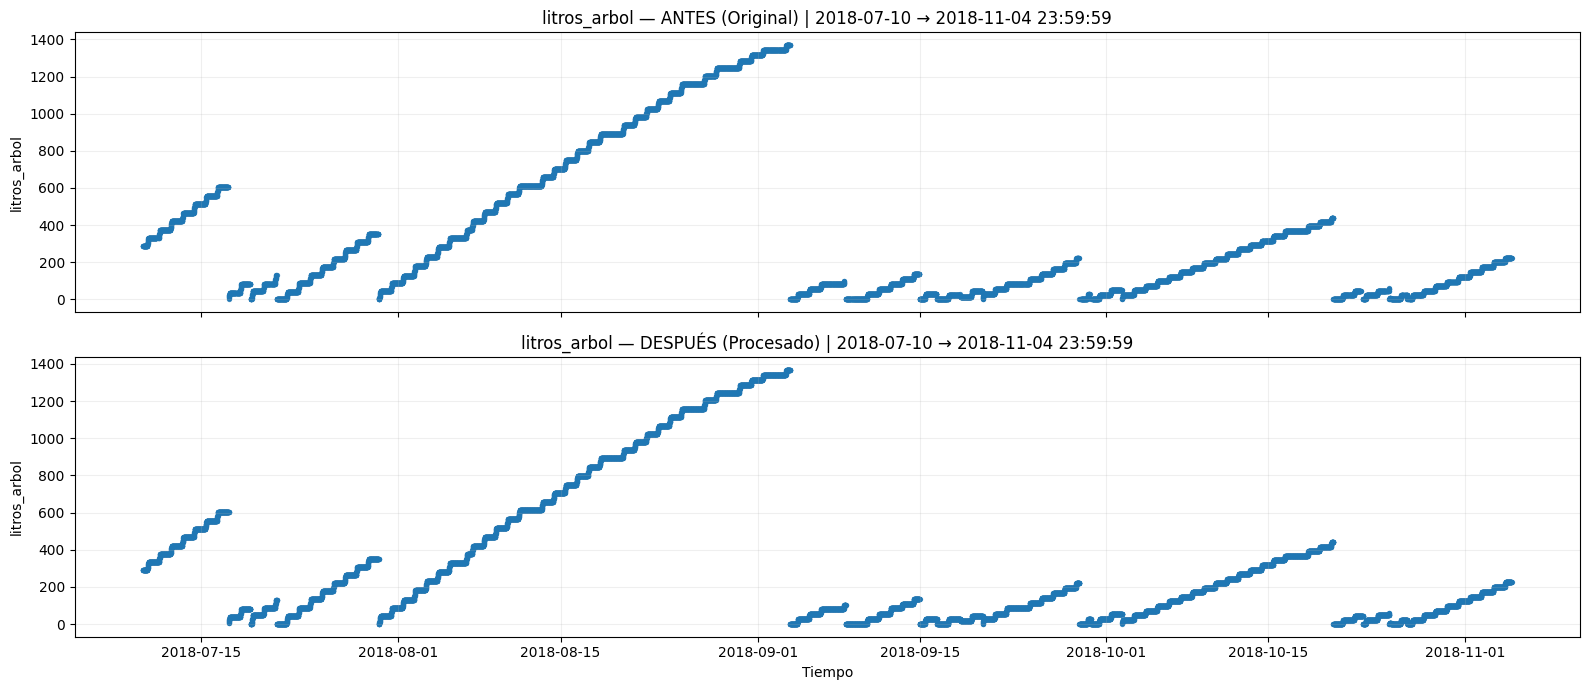

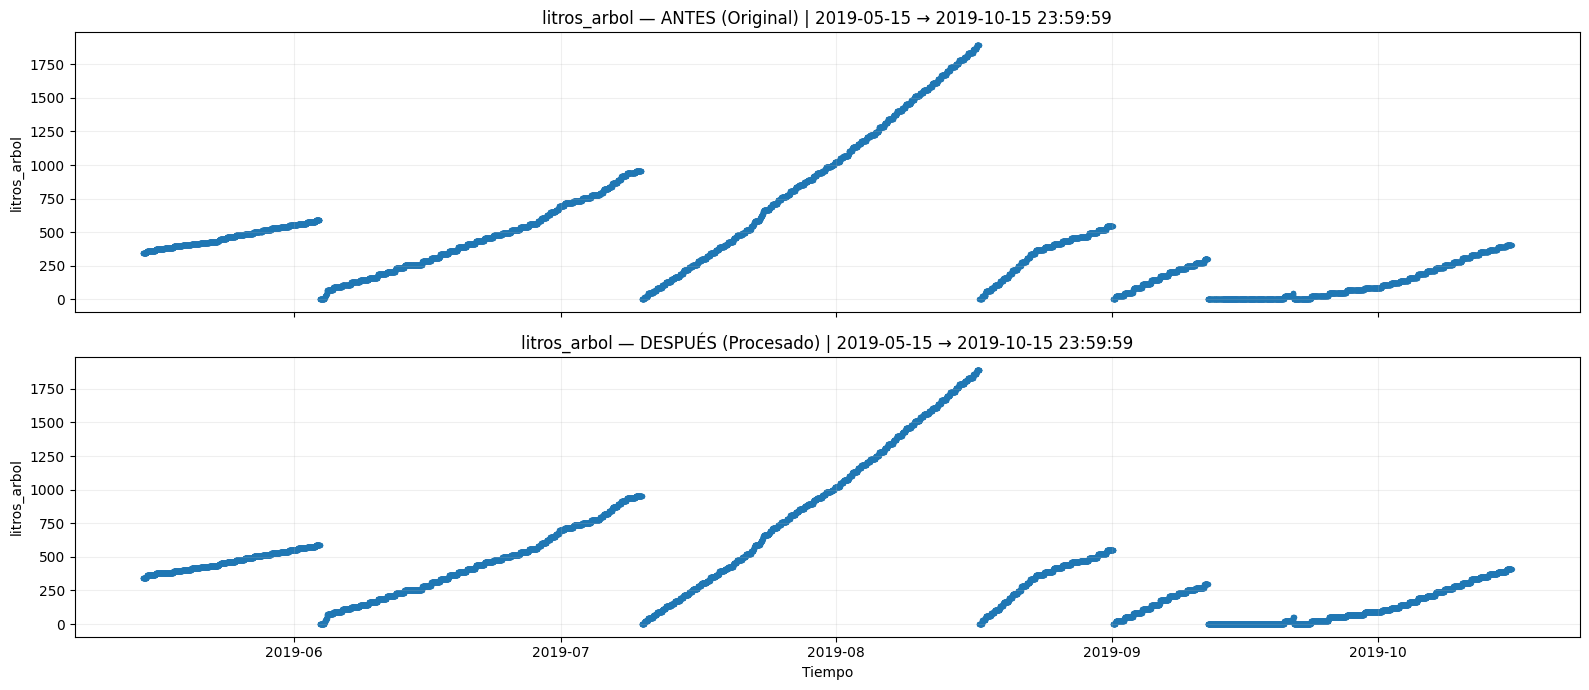

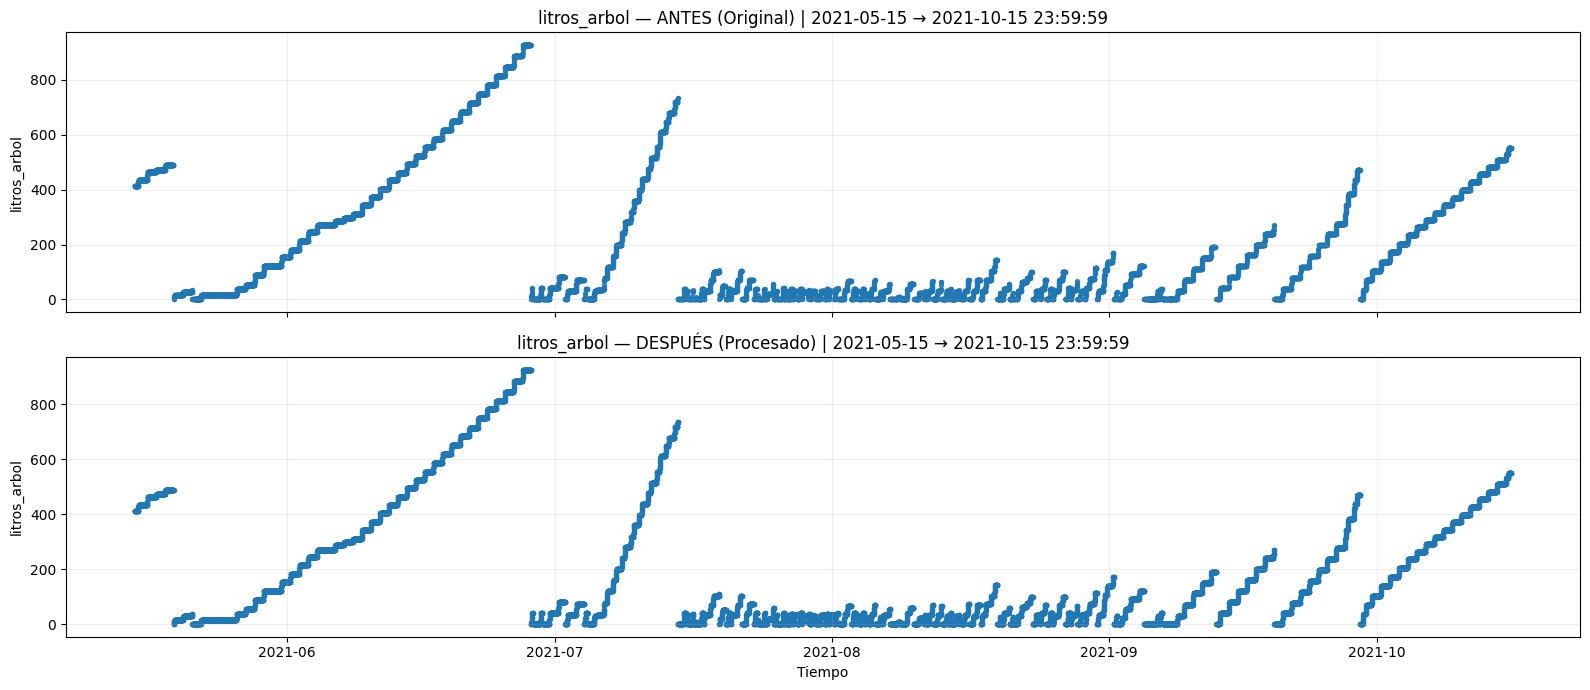

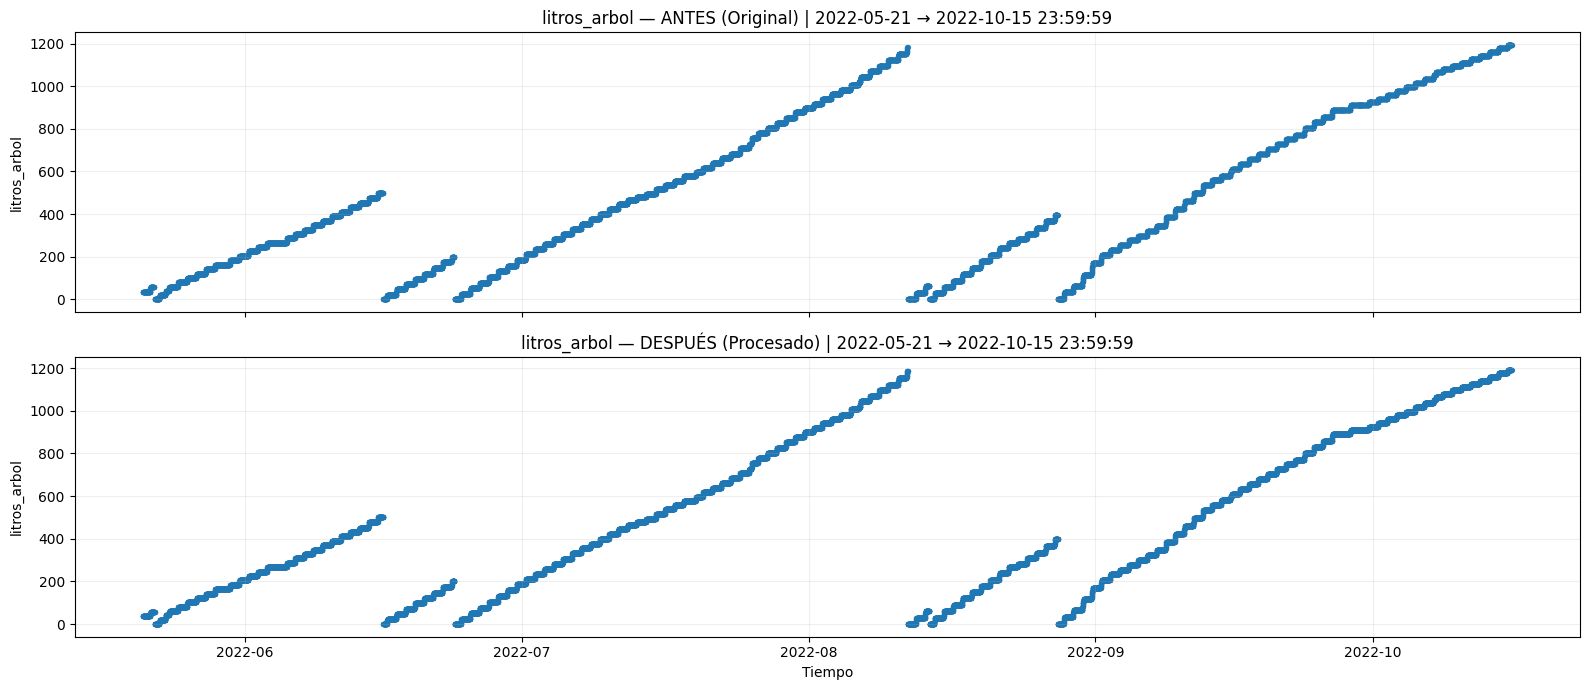

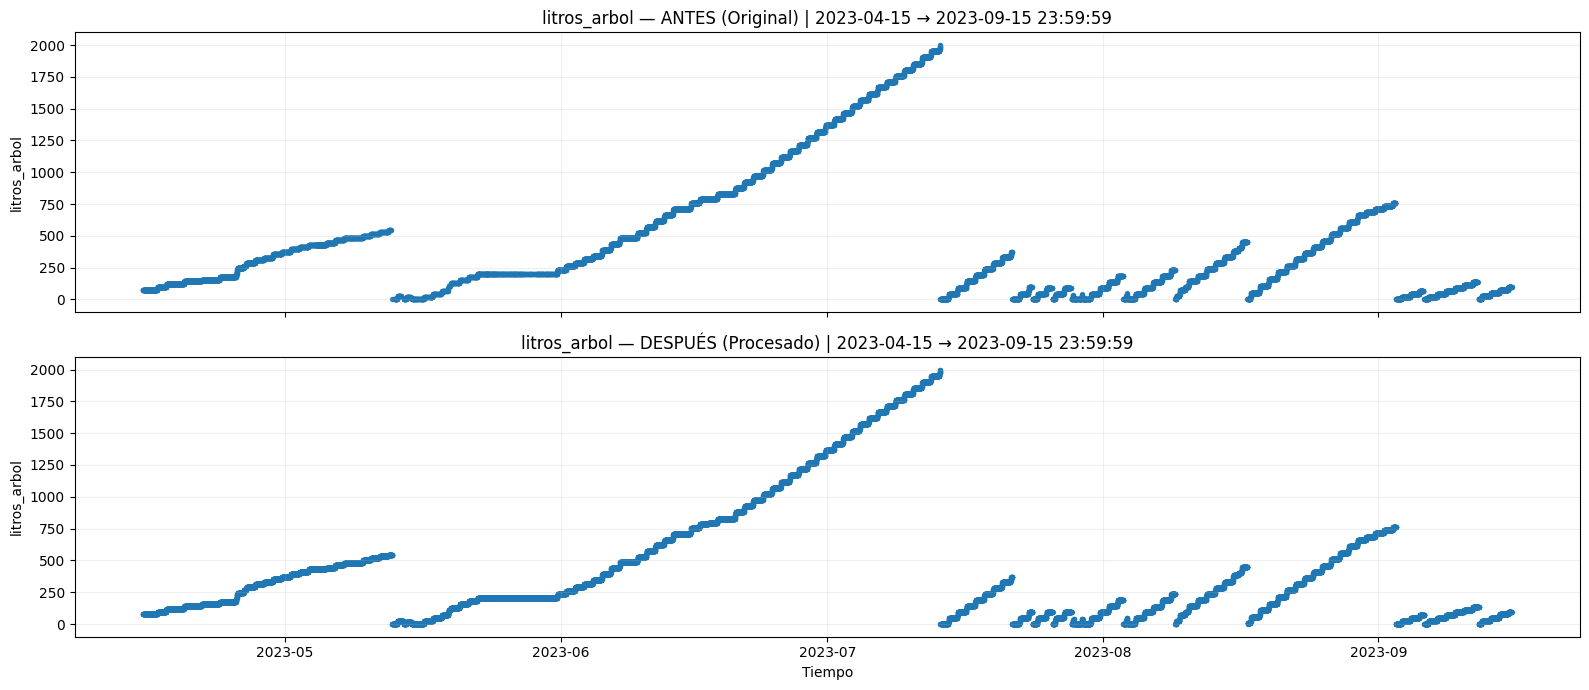

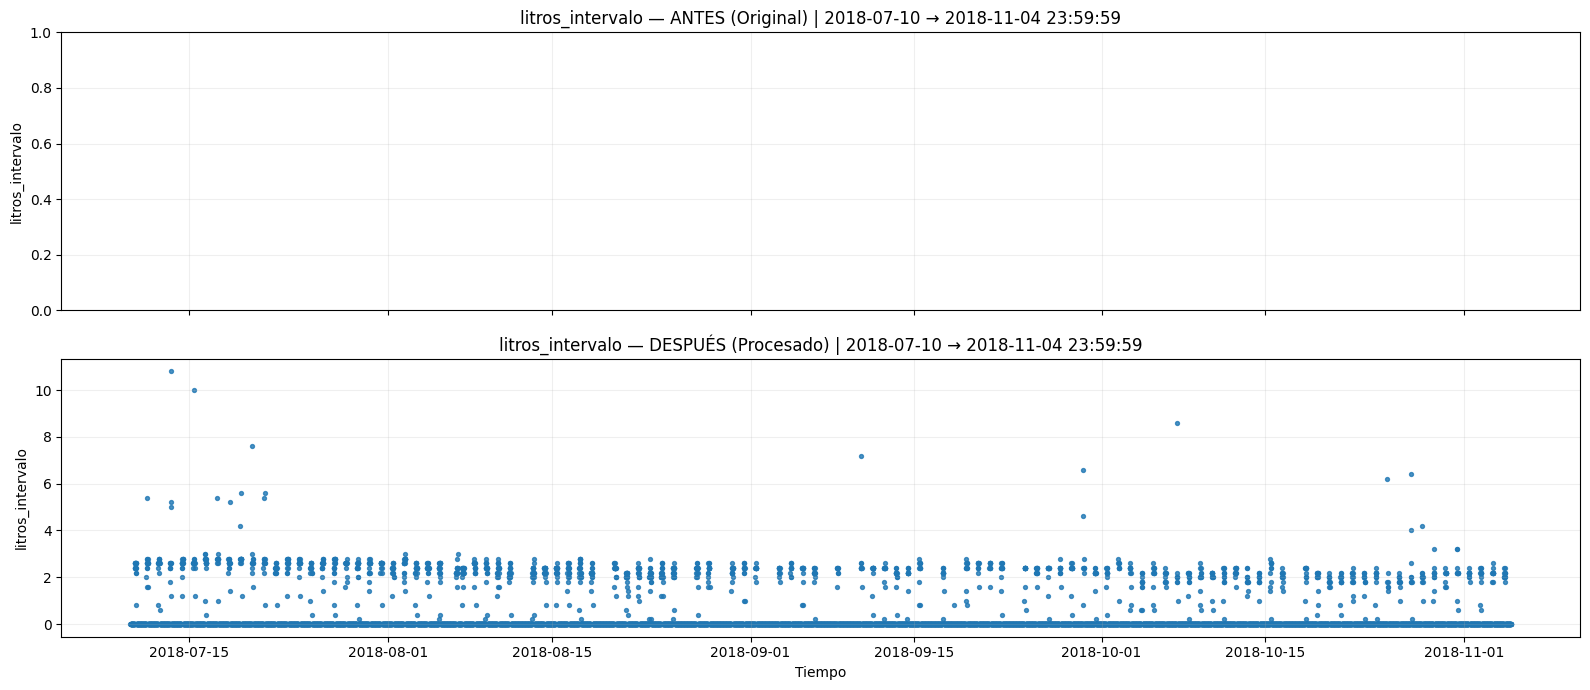

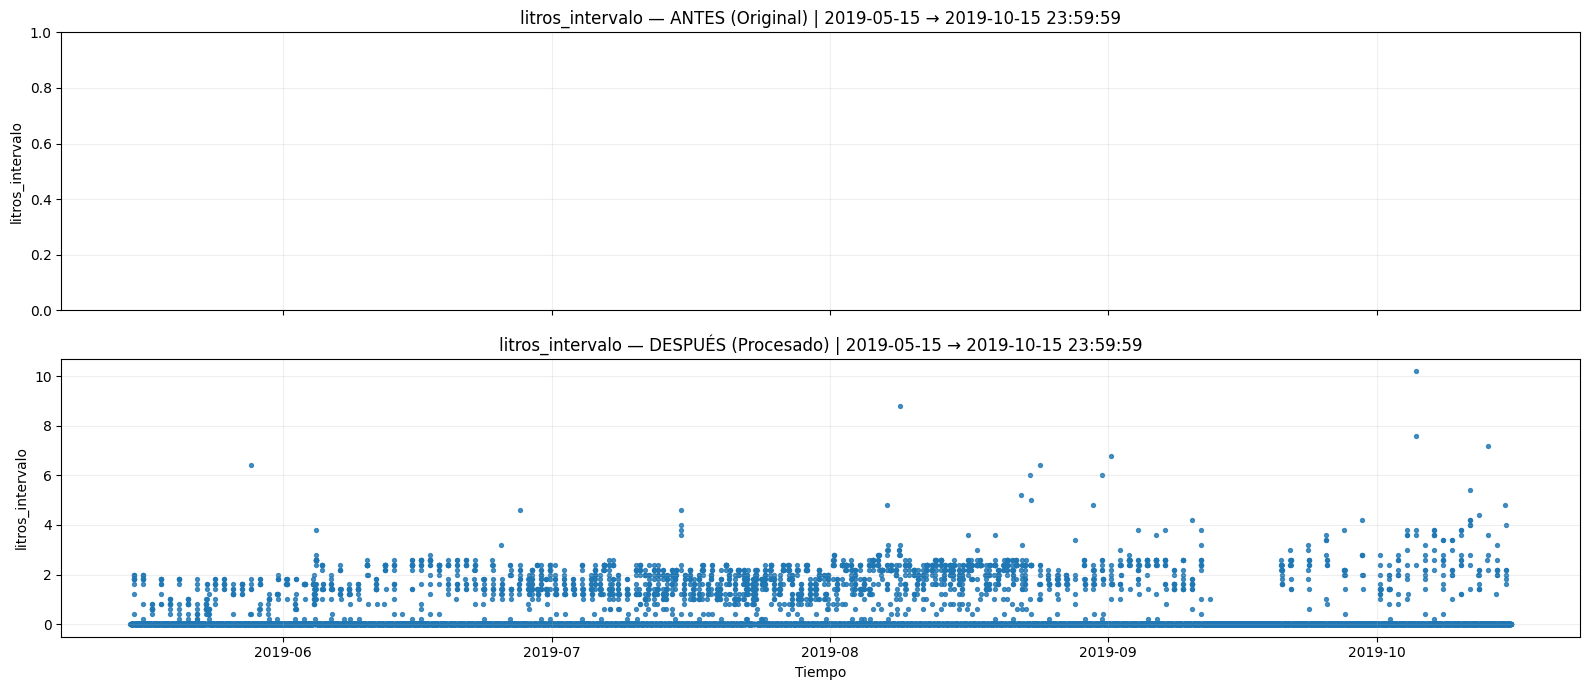

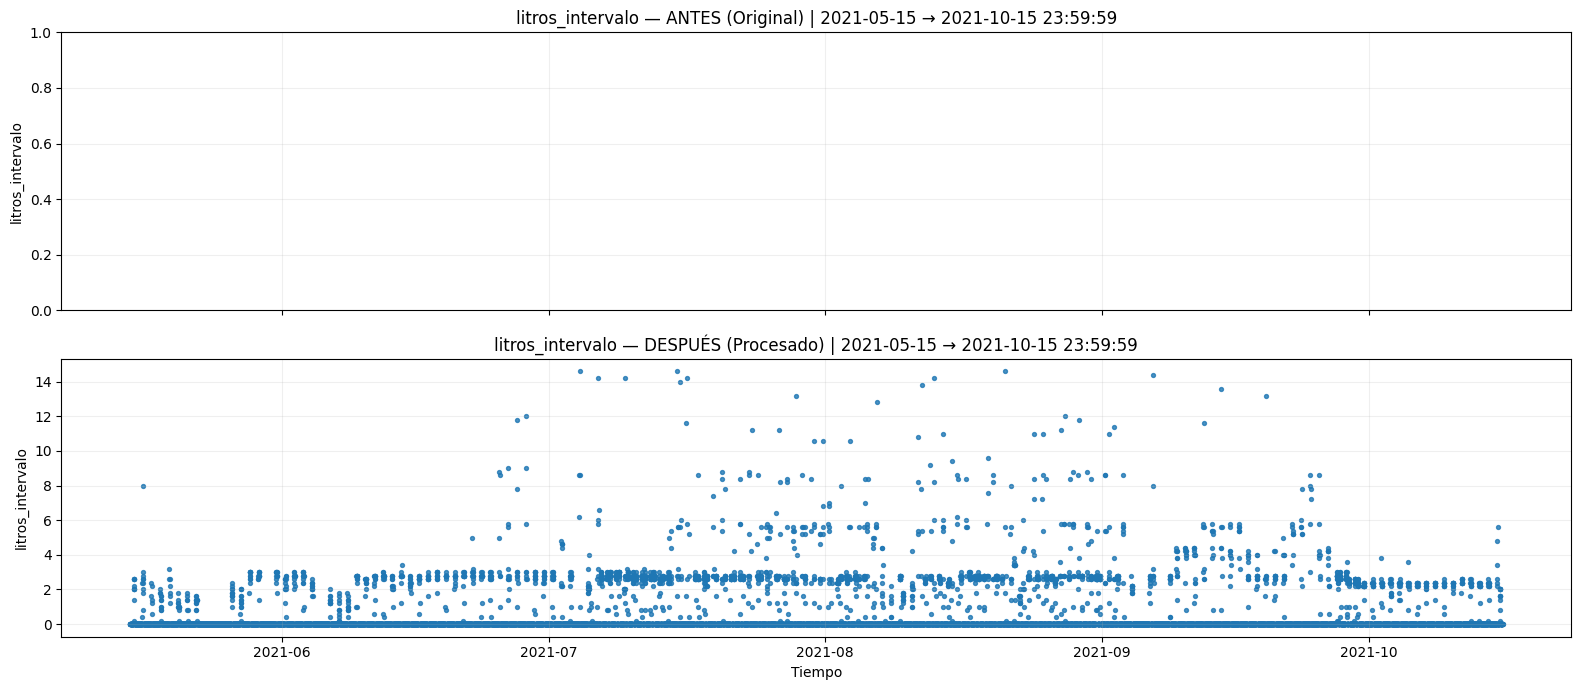

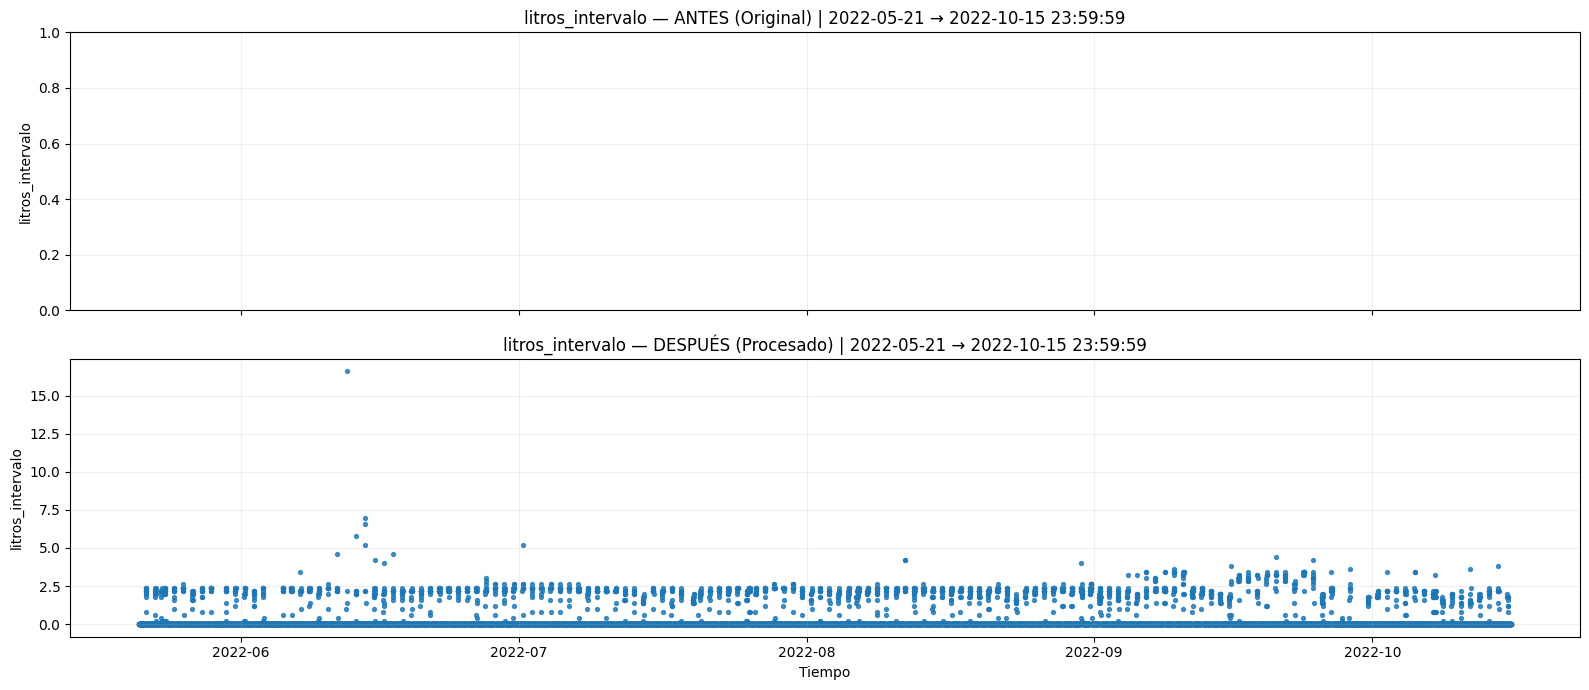

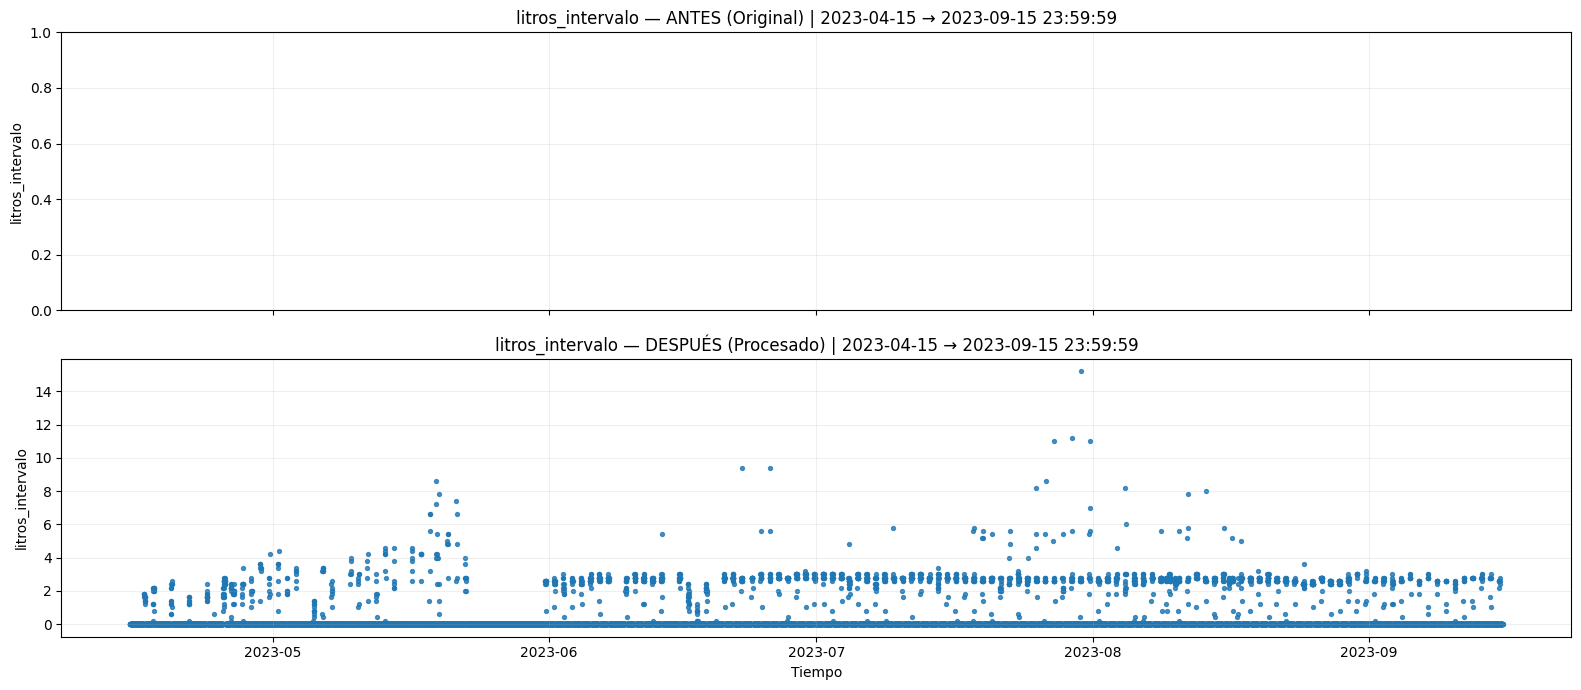

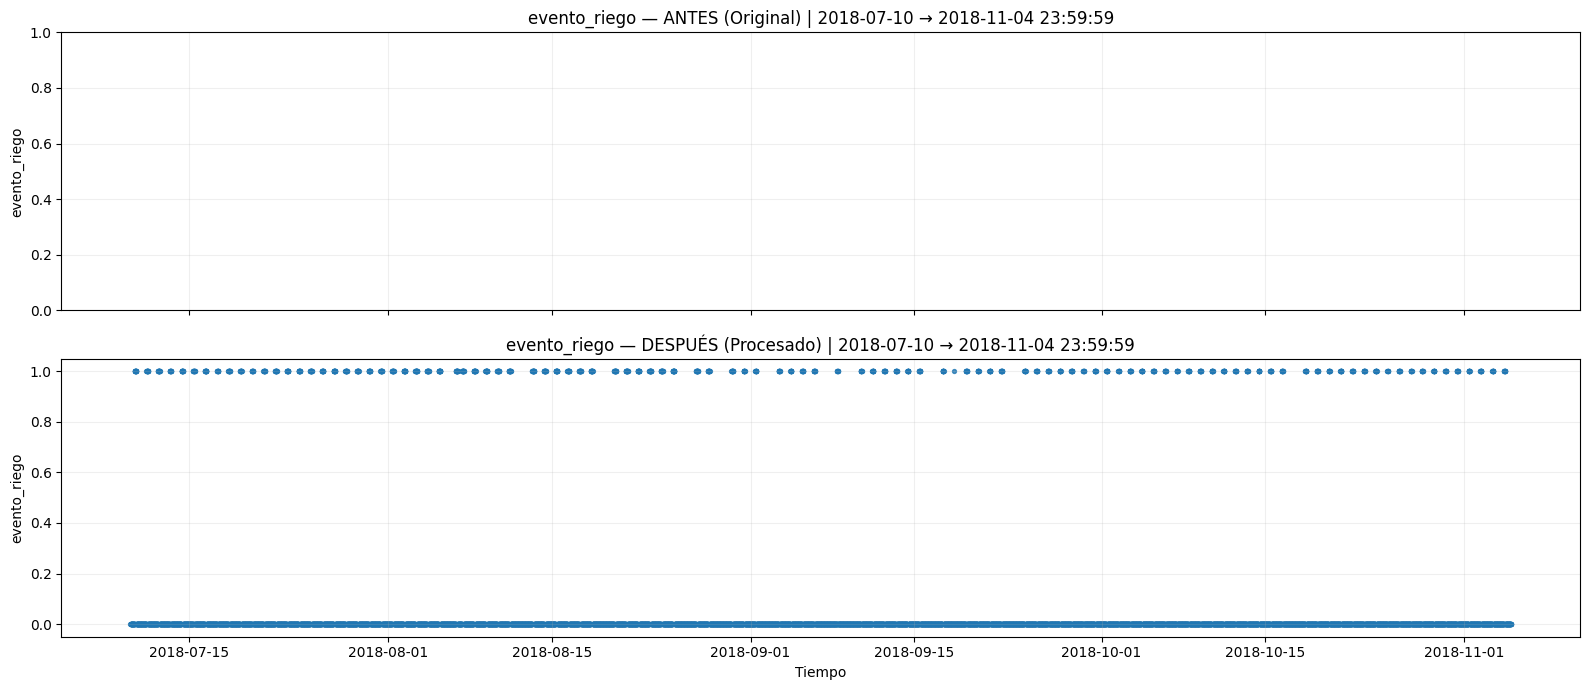

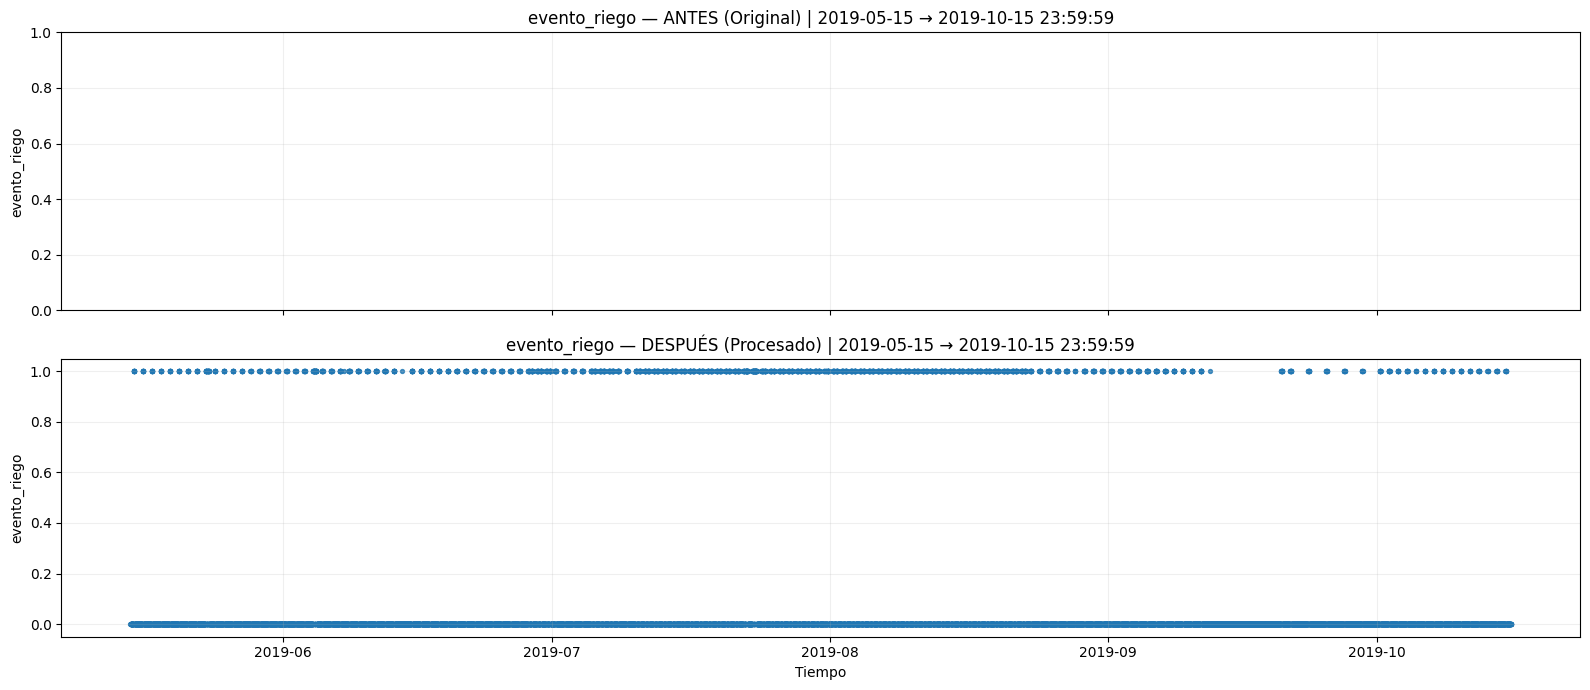

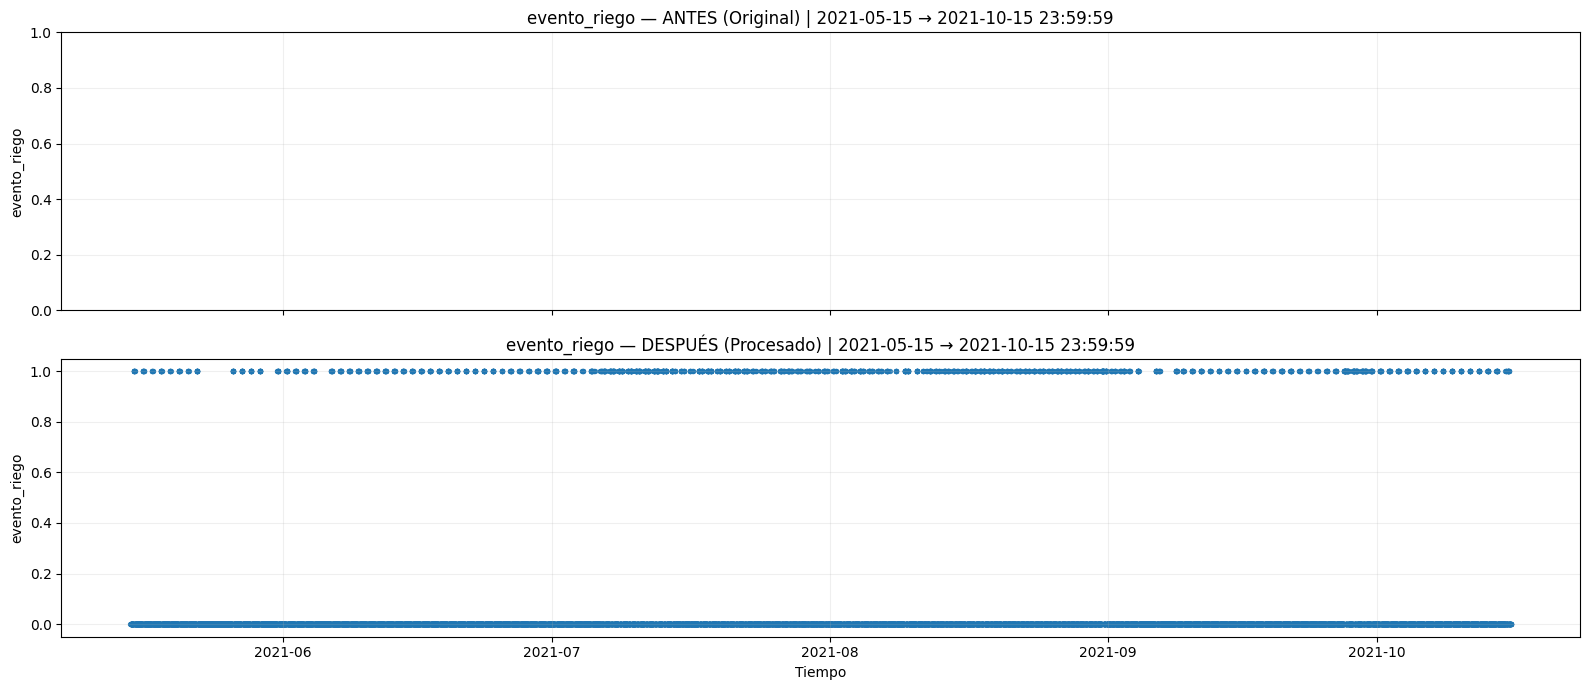

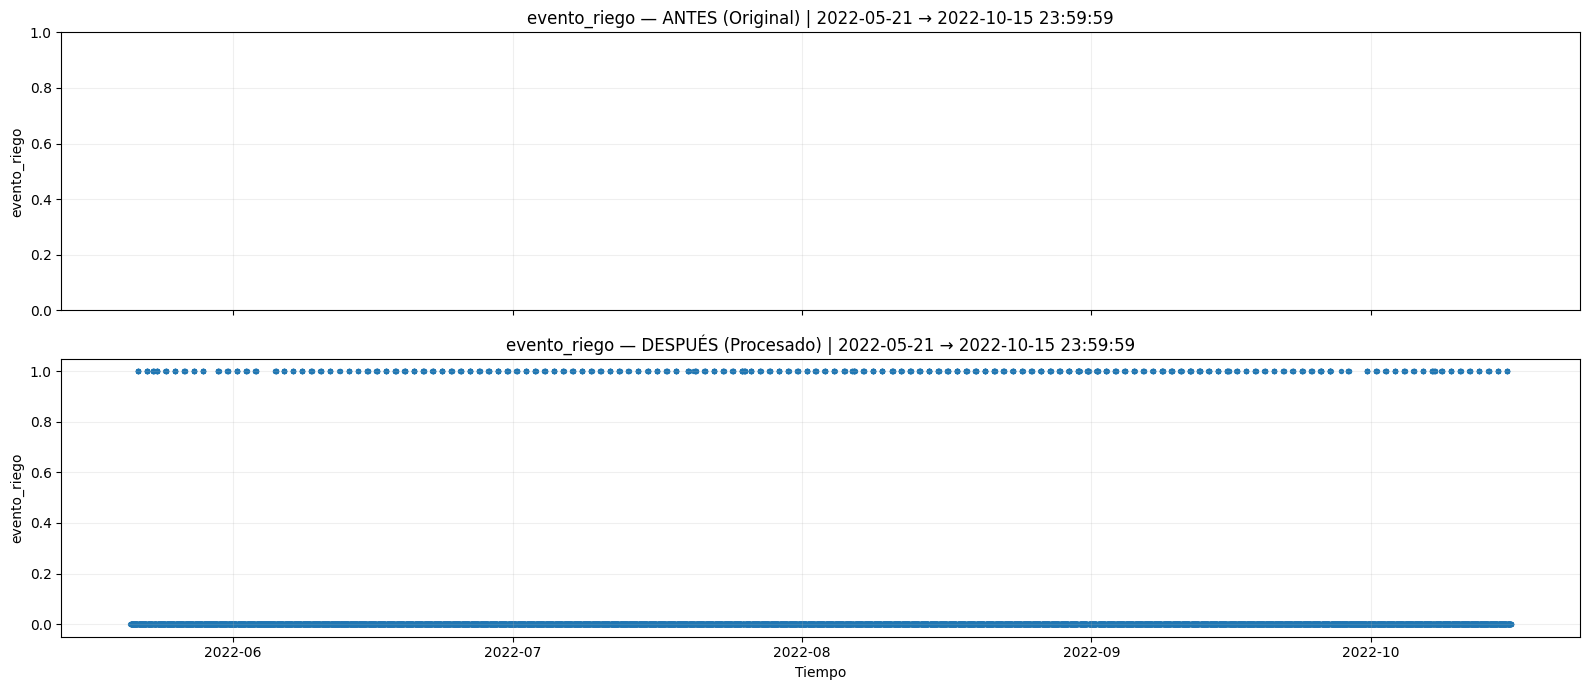

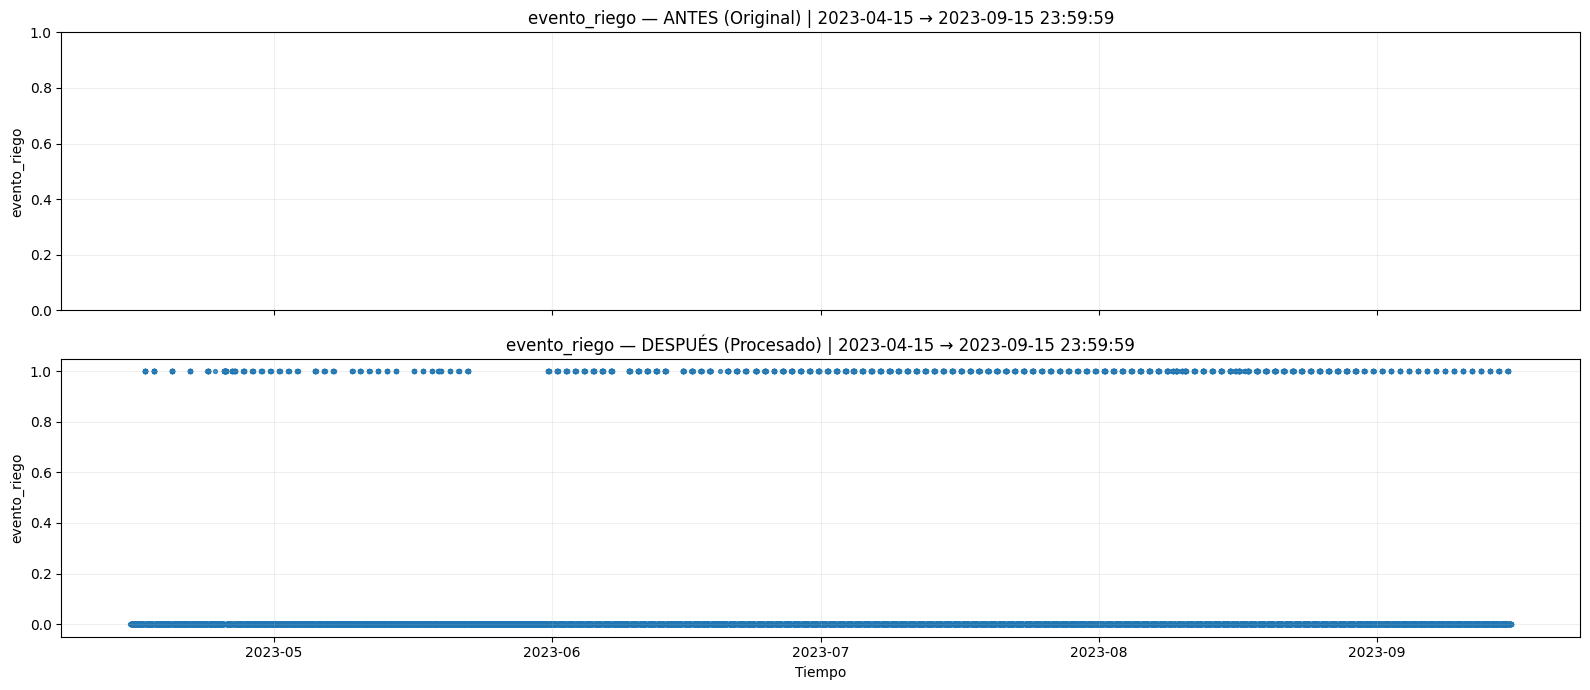

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


data = pd.read_csv("year_all.csv")
data["instante"] = pd.to_datetime(data["instante"])

# Corrección HA (igual que en el preproceso)
data = data.drop(columns=["HA"], errors="ignore")
data = data.rename(columns={"var9": "HA"})

# Nodo 4 (ANTES)
df_before = data[data["id_nodo"] == 4].copy()
df_before = df_before.sort_values("instante").drop(columns=["id_nodo"], errors="ignore")

# DESPUÉS
df_after = pd.read_csv("data_clean_interpolated.csv")
df_after["instante"] = pd.to_datetime(df_after["instante"])
df_after = df_after.sort_values("instante")

# Periodos del TFG
PERIODOS = [
    ("2018-07-10", "2018-11-04 23:59:59"),
    ("2019-05-15", "2019-10-15 23:59:59"),
    ("2021-05-15", "2021-10-15 23:59:59"),
    ("2022-05-21", "2022-10-15 23:59:59"),
    ("2023-04-15", "2023-09-15 23:59:59"),
]

# -----------------------------
# 1) Helper: filtrar por periodo
# -----------------------------
def slice_period(df, start, end):
    start = pd.to_datetime(start)
    end = pd.to_datetime(end)
    return df[(df["instante"] >= start) & (df["instante"] <= end)].copy()

# -----------------------------
# 2) Plot antes vs después (un periodo, una variable)
# -----------------------------
def plot_before_after_period(var, start, end, df_before, df_after, kind="scatter"):
    b = slice_period(df_before, start, end)
    a = slice_period(df_after, start, end)

    fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

    # --- Antes
    if var in b.columns:
        if kind == "line":
            axes[0].plot(b["instante"], b[var], linewidth=1)
        else:
            axes[0].scatter(b["instante"], b[var], s=8, alpha=0.8)
    axes[0].set_title(f"{var} — ANTES (Original) | {start} → {end}")
    axes[0].set_ylabel(var)
    axes[0].grid(True, alpha=0.2)

    # --- Después
    if var in a.columns:
        if kind == "line":
            axes[1].plot(a["instante"], a[var], linewidth=1)
        else:
            axes[1].scatter(a["instante"], a[var], s=8, alpha=0.8)
    axes[1].set_title(f"{var} — DESPUÉS (Procesado) | {start} → {end}")
    axes[1].set_xlabel("Tiempo")
    axes[1].set_ylabel(var)
    axes[1].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

# -----------------------------
# 3) Plot para TODOS los periodos (una variable)
# -----------------------------
def plot_var_all_periods(var, df_before, df_after, periodos=PERIODOS, kind="scatter"):
    for start, end in periodos:
        plot_before_after_period(var, start, end, df_before, df_after, kind=kind)

# -----------------------------
# 4) Plot “batch”: varias variables
# -----------------------------
def plot_many_vars(vars_list, df_before, df_after, periodos=PERIODOS, kind="scatter"):
    for var in vars_list:
        if var not in df_before.columns and var not in df_after.columns:
            print(f"[Aviso] {var} no está en columnas.")
            continue
        print(f"\n=== Variable: {var} ===")
        plot_var_all_periods(var, df_before, df_after, periodos=periodos, kind=kind)


# =========================================================
# EJEMPLOS DE USO
# =========================================================

# 1) Una variable, todos los periodos:
#plot_var_all_periods("dendrometro", df_before, df_after, kind="line")
plot_var_all_periods("litros_arbol", df_before, df_after, kind="scatter")
plot_var_all_periods("litros_intervalo", df_before, df_after, kind="scatter")
plot_var_all_periods("evento_riego", df_before, df_after, kind="scatter")
# 3) Varias variables de golpe:
#vars_to_check = ["HA", "TA", "HS60","TS30", "dendrometro"]
#plot_many_vars(vars_to_check, df_before, df_after, kind="line")
